## **AI Job Market : Exploratory Data Analysis**

The AI job market is rapidly evolving, making it difficult for job seekers and industry leaders to understand the current landscape. This analysis seeks to answer critical questions such as: What are the most financially rewarding skills? and How does compensation vary by experience level and location?"

"The primary objective of this project is to conduct a comprehensive Exploratory Data Analysis (EDA) on the global Artificial Intelligence job market to extract actionable insights.



#### Questions I'm Trying to Answer
1. Which industry has the most job openings?

2. How does the median salary vary for different jobs?

3. Which are the top-paying and most in-demand skills?

4. Do experience level and company size affect salary?

5. What are the most preferred tools by companies?

6. How have job postings trended over the months?

#### Data Importing and Cleaning

In [2]:
# Importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Importing dataset
file_path = r'D:\Projects\Python Projects\AI Job Market Analysis\AI_jobs_dataset\AI_job_market.csv'

df = pd.read_csv(file_path).copy()

# Deleting duplicate values if exist
df_cleaned = df.drop_duplicates(inplace=False)

# Converting 'skills_required' & 'tools_preferred' column from string to list
df_cleaned['skills_required'] = df_cleaned['skills_required'].str.split(',')
df_cleaned['tools_preferred'] = df_cleaned['tools_preferred'].str.split(',')

# Converting 'posted_date' column from string to datetime
df_cleaned['posted_date'] = pd.to_datetime(df_cleaned['posted_date'],dayfirst = True)

# Setting 'job_id' as index
df_cleaned.set_index('job_id', inplace = True)

#### Analyzing Data For Insights

In [4]:
# Finding the total number of rows & columns in the dataset and their respective datatypes
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 1 to 2000
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   company_name      2000 non-null   object        
 1   industry          2000 non-null   object        
 2   job_title         2000 non-null   object        
 3   skills_required   2000 non-null   object        
 4   experience_level  2000 non-null   object        
 5   employment_type   2000 non-null   object        
 6   location          2000 non-null   object        
 7   median_salary     2000 non-null   int64         
 8   posted_date       2000 non-null   datetime64[ns]
 9   company_size      2000 non-null   object        
 10  tools_preferred   2000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 187.5+ KB


In [5]:
# salary insights
df_cleaned['median_salary'].describe()

count      2000.0000
mean     123040.2500
std       34776.1933
min       47579.0000
25%       94466.7500
50%      123203.0000
75%      151413.5000
max      197777.0000
Name: median_salary, dtype: float64

In [6]:
# List of all the jobs in the job postings
AI_jobs = df_cleaned['job_title'].unique().tolist()
AI_jobs

['Data Analyst',
 'Computer Vision Engineer',
 'Quant Researcher',
 'AI Product Manager',
 'Data Scientist',
 'ML Engineer',
 'NLP Engineer',
 'AI Researcher']

### 1. Which industry has the most job openings?

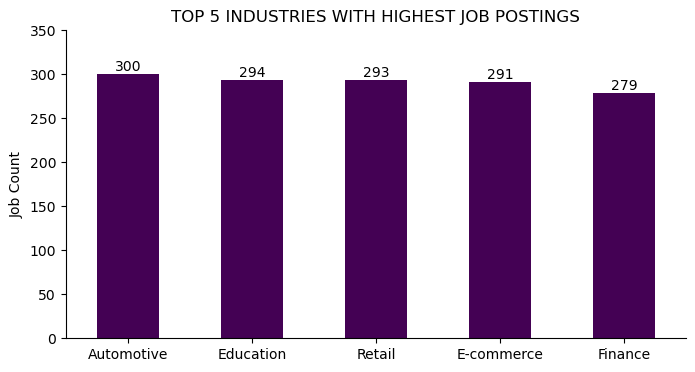

In [7]:
# Filtering the top 5 industries with the highest job postings
df_industries = df_cleaned['industry'].value_counts().head().reset_index()

# Using bar plot for visualization
ax = df_industries.plot(kind = 'bar', x = 'industry', y ='count', legend = False, colormap = 'viridis', figsize = (8,4))

# Customizing visualization
plt.title('TOP 5 INDUSTRIES WITH HIGHEST JOB POSTINGS')
plt.xlabel('')
plt.ylabel('Job Count')
plt.xticks(rotation = 0)
plt.ylim(0,350)
ax.bar_label(ax.containers[0])
sns.despine()
plt.show()

### 2. How does the median salary vary for different jobs?

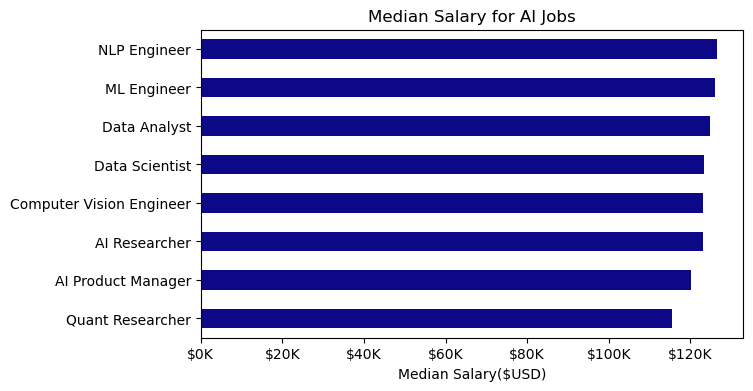

In [8]:
# Filtering job titles and their corresponding median salaries
df_job_salary = df_cleaned.groupby('job_title')['median_salary'].median().sort_values(ascending = False)

# Using horizontal bar plot for visualization
ax = df_job_salary.plot(kind ='barh', style = 'ticks', colormap = 'plasma', figsize = (7,4))

# Customizing visualization
ax.invert_yaxis()
ax.set_ylabel('')
ax.set_title('Median Salary for AI Jobs')
ax.set_xlabel('Median Salary($USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'${int(x/1000)}K'))

### 3. Which are the top-paying and most in-demand skills?

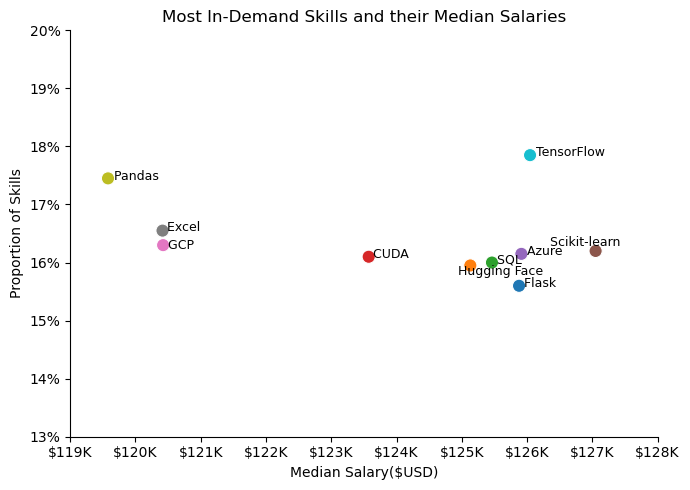

In [9]:
# Exploding the skills_required column to convert the skill list into individual skills
df_explode = df_cleaned.explode('skills_required')

# Filtering the skills required in most job postings and their median salaries
df_skill_count = df_explode.groupby('skills_required')['median_salary'].agg(['count','median']).sort_values(by = 'count', ascending = False).head(10)
df_skill_count.rename(columns={'count' : 'skill_count', 'median' : 'median_salary'},inplace = True)

# Total job postings
total_jobs = len(df_cleaned)


# Creating a new column to find the proportion of each skill in the job postings
df_skill_perc = df_explode['skills_required'].value_counts().reset_index(name = 'skill_count')
df_skill_perc['skill_perc'] = (df_skill_perc['skill_count'] / total_jobs ) * 100

# Merging the two columns 
df_plot =  pd.merge(left = df_skill_count, right = df_skill_perc.drop(columns = 'skill_count'), how = 'left', on = 'skills_required',)

skill_name = df_plot['skills_required'].to_list()
sal_list = df_plot['median_salary'].to_list()
perc_list = df_plot['skill_perc'].to_list()

# Using a scatter plot for visualization
plt.figure(figsize=(7, 5)) # A wider figure gives more room on the sides
ax = sns.scatterplot(data = df_plot, x = 'median_salary', y = 'skill_perc', s = 90, hue = 'skill_perc', palette = 'tab10', legend =False)

# Customizing visualization
sns.despine()

texts = []

for i, skill in enumerate(skill_name):
    texts.append(plt.text(sal_list[i], perc_list[i] , skill, fontsize = 9))

# Adjusting text label
from adjustText import adjust_text

adjust_text(
    texts, 
    force_text=5.0,    
    force_points=2.0,   
)

ax.set_title('Most In-Demand Skills and their Median Salaries')
ax.set_xlim(119000,128000)
ax.set_xlabel('Median Salary($USD)')
ax.set_ylabel('Proportion of Skills')
ax.set_ylim(13,20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : f'${int(x/1000)}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos : f'{int(y)}%'))
plt.tight_layout()
plt.show()

### 4. Do experience level and company size affect salary?

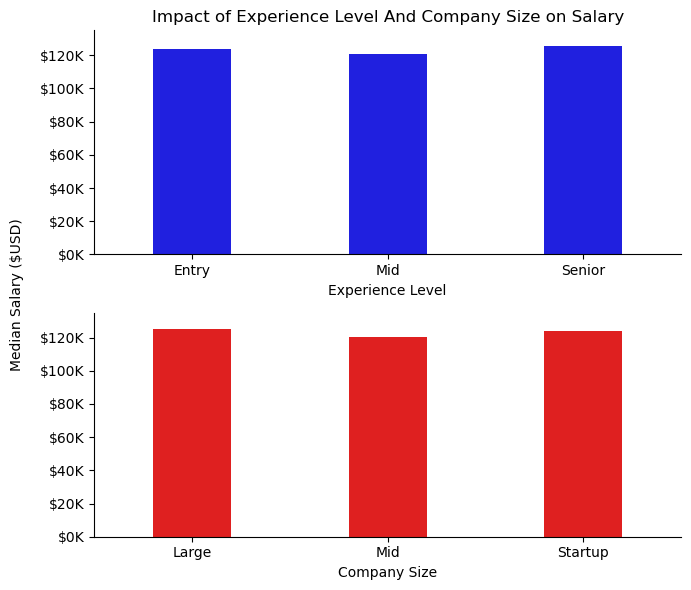

In [10]:
# Creating new dataframes to find how the experience level and company size impact salary
df_exp_lvl = df_cleaned.groupby('experience_level')['median_salary'].median().to_frame()
df_com_size = df_cleaned.groupby('company_size')['median_salary'].median().to_frame()

# Using a barplot for visualization
fig, ax = plt.subplots(2,1, figsize = (7,6))
sns.barplot(data = df_exp_lvl, x = 'experience_level', y = 'median_salary', ax= ax[0], color = 'blue', width = 0.4)
sns.barplot(data = df_com_size, x = 'company_size', y = 'median_salary', ax= ax[1], color = 'red', width = 0.4)
sns.despine()

# Customizing the visualization
ax[0].set_ylim(0,135000)
ax[1].set_ylim(0,135000)
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_xlabel('Experience Level')
ax[1].set_xlabel('Company Size')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
fig.supylabel('Median Salary ($USD)', fontsize=10)
ax[0].set_title('Impact of Experience Level And Company Size on Salary')
plt.tight_layout()
plt.show()

### 5. What are the most preferred tools by companies?

Text(0.5, 0, 'Tool Count')

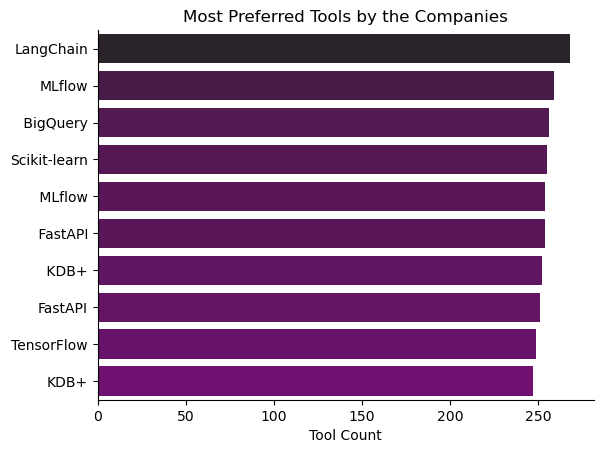

In [47]:
# Exploding the tools_preferred column 
df_tools_explode = df_cleaned.explode('tools_preferred')

# Finding the top 10 most preferred tools by companies
df_tools = df_tools_explode['tools_preferred'].value_counts().head(10).reset_index(name = 'tool_count')

# Plotting horizontal bar chart using seaborn
sns.barplot(data =  df_tools, x = 'tool_count', y = 'tools_preferred', hue = 'tool_count', palette = 'dark:purple_r', legend =False)
sns.despine()

# Customizing the visualization
plt.title('Most Preferred Tools by the Companies')
plt.ylabel('')
plt.xlabel('Tool Count')

### 6. How have job postings trended over the months?

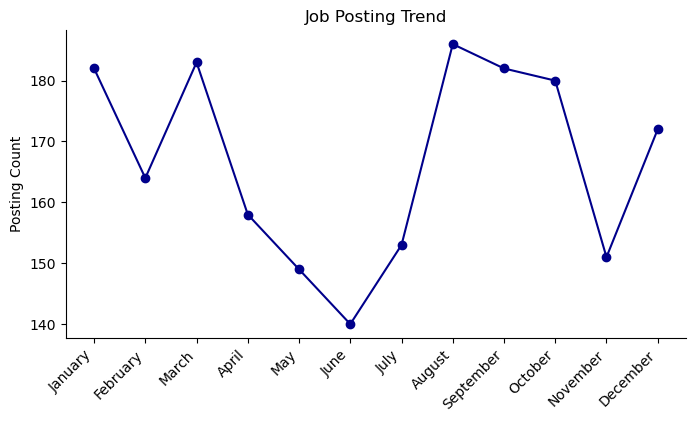

In [163]:
# Finding the job posting count for each month
df_month = pd.to_datetime(df_cleaned['posted_date']).dt.month_name().value_counts().reset_index()
df_month['date_object'] = pd.to_datetime('1-' + df_month['posted_date'], format='%d-%B')
df_month['month_no'] = pd.to_datetime(df_month['date_object']).dt.month
df_month.drop(columns ='date_object', inplace =True)
df_month.sort_values(by = 'month_no', inplace = True)
df_month.set_index('posted_date')

# # Plotting line chart for visualization
ax = df_month.plot(kind = 'line', x = 'month_no', y = 'count', figsize = (8,4), legend = False, marker='o', color = 'darkblue')
sns.despine()

# Customizing Visualization
ax.set_xticks(df_month['month_no'])
ax.set_xticklabels(df_month['posted_date'].str[:])
plt.xticks(rotation = 45, ha = 'right')
plt.title('Job Posting Trend')
plt.xlabel('')
plt.ylabel('Posting Count')
plt.show()
